Dataset Shape     : (5000, 17)
Number of Rows    : 5000
Original Features : 16
Target Variable   : Purchased

ORIGINAL FEATURES

1 . Age
2 . Annual_Income
3 . Credit_Score
4 . Family_Size
5 . Existing_Loan
6 . House_Price
7 . House_Area
8 . Bedrooms
9 . Bathrooms
10 . Distance_to_Work
11 . Down_Payment
12 . Location_Score
13 . Employment_Years
14 . Monthly_Expenses
15 . Property_Tax
16 . Maintenance_Cost

SELECTED FEATURES

1 . Age
2 . Annual_Income
3 . Credit_Score
4 . Family_Size
5 . Existing_Loan
6 . House_Price
7 . House_Area
8 . Bedrooms
9 . Bathrooms
10 . Down_Payment
11 . Location_Score
12 . Monthly_Expenses
13 . Property_Tax
14 . Maintenance_Cost

ENGINEERED FEATURES

1 . Price_Per_SqFt
2 . Income_Price_Ratio
3 . Loan_Burden
4 . DownPayment_Ratio
5 . Expense_to_Income
6 . Space_Per_Person

FEATURE COUNT

Original   : 16
Selected   : 14
Engineered : 22


FINAL RESULTS

              Model Feature Set  Accuracy  Precision  Recall  F1 Score
Logistic Regression    Original     0.82

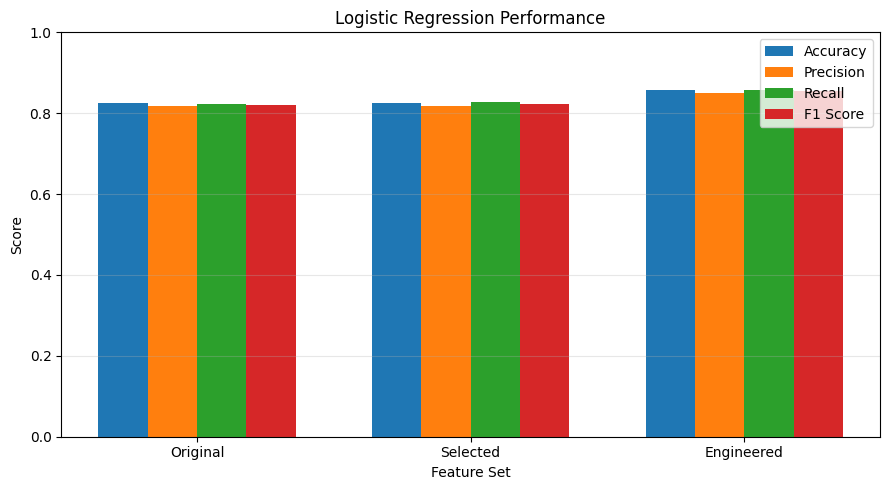

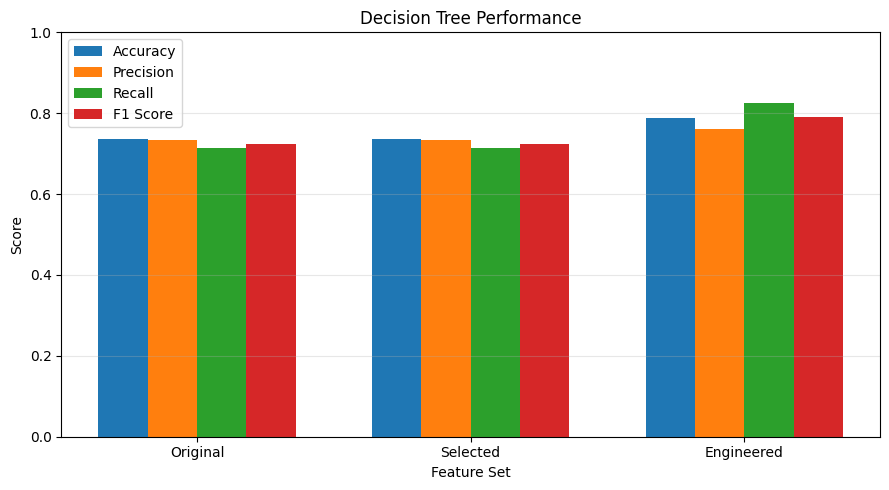


BEST RESULT
Model       : Logistic Regression
Feature Set : Engineered
Accuracy    : 0.858
Precision   : 0.851
Recall      : 0.858
F1 Score    : 0.854


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score)

df = pd.read_csv("/content/house_purchase_prediction_features.csv")
X = df.drop("Purchased", axis=1)
y = df["Purchased"]
print("Dataset Shape     :", df.shape)
print("Number of Rows    :", df.shape[0])
print("Original Features :", X.shape[1])
print("Target Variable   : Purchased")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

print("\nORIGINAL FEATURES\n")
for i, feature in enumerate(X.columns, 1):
    print(i, ".", feature)

selector = SelectKBest(score_func=f_classif,k=14)

X_train_selected = selector.fit_transform(
    X_train,
    y_train)
X_test_selected = selector.transform(
    X_test)
selected_features = list(
    X_train.columns[selector.get_support()])

print("\nSELECTED FEATURES\n")

for i, feature in enumerate(selected_features, 1):
    print(i, ".", feature)

X_engineered = X.copy()
X_engineered["Price_Per_SqFt"] = (
    X_engineered["House_Price"] /
    X_engineered["House_Area"])

X_engineered["Income_Price_Ratio"] = (
    X_engineered["Annual_Income"] /
    X_engineered["House_Price"])

X_engineered["Loan_Burden"] = (
    X_engineered["Existing_Loan"] /
    X_engineered["Annual_Income"])

X_engineered["DownPayment_Ratio"] = (
    X_engineered["Down_Payment"] /
    X_engineered["House_Price"])

X_engineered["Expense_to_Income"] = (
    X_engineered["Monthly_Expenses"] /
    (X_engineered["Annual_Income"] / 12))

X_engineered["Space_Per_Person"] = (
    X_engineered["House_Area"] /
    X_engineered["Family_Size"])

X_engineered = X_engineered.replace(
    [np.inf, -np.inf],
    np.nan).fillna(0)

engineered_features = [
    "Price_Per_SqFt",
    "Income_Price_Ratio",
    "Loan_Burden",
    "DownPayment_Ratio",
    "Expense_to_Income",
    "Space_Per_Person"]

print("\nENGINEERED FEATURES\n")

for i, feature in enumerate(engineered_features, 1):
    print(i, ".", feature)

print("\nFEATURE COUNT\n")
print("Original   :", X.shape[1])
print("Selected   :", len(selected_features))
print("Engineered :", X_engineered.shape[1])

X_train_eng, X_test_eng, y_train_eng, y_test_eng = train_test_split(
    X_engineered,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y)

def evaluate(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    prediction = model.predict(Xte)

    return [
        accuracy_score(yte, prediction),
        precision_score(yte, prediction, zero_division=0),
        recall_score(yte, prediction, zero_division=0),
        f1_score(yte, prediction, zero_division=0)]

results = []

scaler = StandardScaler()

Xtr = scaler.fit_transform(X_train)
Xte = scaler.transform(X_test)

log_original = LogisticRegression(
    max_iter=1000,
    random_state=42)

m = evaluate(
    log_original,
    Xtr,
    Xte,
    y_train,
    y_test)

results.append(
    ["Logistic Regression", "Original"] + m)

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train_selected)
Xte = scaler.transform(X_test_selected)
log_selected = LogisticRegression(
    max_iter=1000,
    random_state=42)

m = evaluate(
    log_selected,
    Xtr,
    Xte,
    y_train,
    y_test)

results.append(
    ["Logistic Regression", "Selected"] + m)

scaler = StandardScaler()
Xtr = scaler.fit_transform(X_train_eng)
Xte = scaler.transform(X_test_eng)
log_engineered = LogisticRegression(
    max_iter=1000,
    random_state=42)

m = evaluate(
    log_engineered,
    Xtr,
    Xte,
    y_train_eng,
    y_test_eng)
results.append(
    ["Logistic Regression", "Engineered"] + m)

tree_original = DecisionTreeClassifier(
    max_depth=6,
    random_state=42)

m = evaluate(
    tree_original,
    X_train,
    X_test,
    y_train,
    y_test)

results.append(
    ["Decision Tree", "Original"] + m)
tree_selected = DecisionTreeClassifier(
    max_depth=6,
    random_state=42)
m = evaluate(
    tree_selected,
    X_train[selected_features],
    X_test[selected_features],
    y_train,
    y_test)
results.append(
    ["Decision Tree", "Selected"] + m)
tree_engineered = DecisionTreeClassifier(
    max_depth=6,
    random_state=42)

m = evaluate(
    tree_engineered,
    X_train_eng,
    X_test_eng,
    y_train_eng,
    y_test_eng)

results.append(
    ["Decision Tree", "Engineered"] + m)
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Feature Set",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"])
print("\n\nFINAL RESULTS\n")

print(results_df.round(3).to_string(index=False))
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"]

log_results = results_df[
    results_df["Model"] == "Logistic Regression"]
x = np.arange(3)
width = 0.18
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        log_results[metric],
        width,
        label=metric)
plt.xticks(x,["Original", "Selected", "Engineered"])
plt.xlabel("Feature Set")
plt.ylabel("Score")
plt.title("Logistic Regression Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

tree_results = results_df[
    results_df["Model"] == "Decision Tree"]
plt.figure(figsize=(9, 5))
for i, metric in enumerate(metrics):
    plt.bar(
        x + (i - 1.5) * width,
        tree_results[metric],
        width,
        label=metric)
plt.xticks(x,["Original", "Selected", "Engineered"])
plt.xlabel("Feature Set")
plt.ylabel("Score")
plt.title("Decision Tree Performance")
plt.ylim(0, 1)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

best = results_df.loc[
    results_df["F1 Score"].idxmax()]

print("\nBEST RESULT")
print("Model       :", best["Model"])
print("Feature Set :", best["Feature Set"])
print("Accuracy    :", round(best["Accuracy"], 3))
print("Precision   :", round(best["Precision"], 3))
print("Recall      :", round(best["Recall"], 3))
print("F1 Score    :", round(best["F1 Score"], 3))